# Galerkin Neural Networks для аппроксимации функций Грина

В этом ноутбуке мы демонстрируем использование нейронных сетей для аппроксимации функций Грина с помощью метода Галёркина.

## 1. Теория

**Функция Грина** - это решение дифференциального уравнения с дельта-функцией в качестве источника:
$$\mathcal{L}G(x, x') = \delta(x - x')$$

где $\mathcal{L}$ - дифференциальный оператор, $G(x, x')$ - функция Грина.

**Метод Галёркина** - это вариационный метод для приближенного решения дифференциальных уравнений, где мы ищем решение в виде разложения по базисным функциям и используем слабую формулировку.

In [48]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Установка seed для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 2. Постановка задачи: Одномерное уравнение Пуассона

Рассмотрим одномерное уравнение Пуассона на отрезке $[0, 1]$:

$$-\frac{d^2 u}{dx^2} = f(x)$$

с граничными условиями Дирихле: $u(0) = u(1) = 0$

Функция Грина для этой задачи имеет аналитическое решение:

$$G(x, x') = \begin{cases}
x(1-x'), & x \leq x' \\
x'(1-x), & x > x'
\end{cases}$$

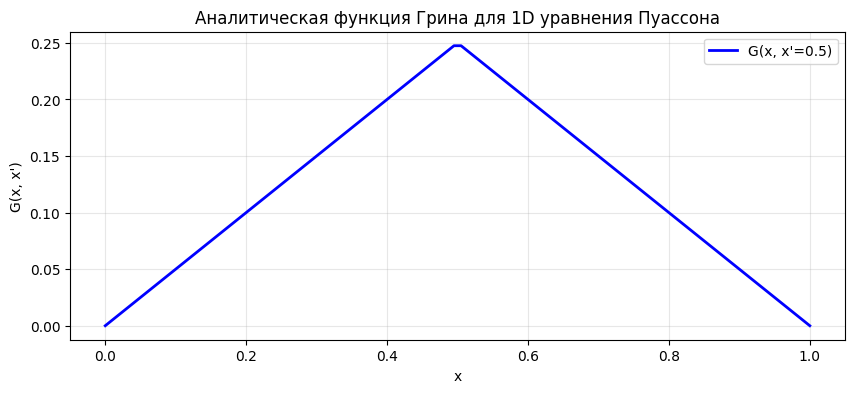

In [49]:
def greens_function_analytical(x, x_prime):
    """
    Аналитическая функция Грина для -d²u/dx² = δ(x - x') на [0,1]
    с граничными условиями u(0) = u(1) = 0
    
    Args:
        x: точка наблюдения (может быть массивом)
        x_prime: точка источника (скаляр или массив)
    
    Returns:
        G(x, x'): значение функции Грина
    """
    x = np.asarray(x)
    x_prime = np.asarray(x_prime)
    
    # Создаем сетку для всех комбинаций x и x'
    if x.ndim == 0:
        x = x.reshape(1)
    if x_prime.ndim == 0:
        x_prime = x_prime.reshape(1)
    
    X, X_prime = np.meshgrid(x, x_prime, indexing='ij')
    
    # Вычисляем функцию Грина
    G = np.where(X <= X_prime, X * (1 - X_prime), X_prime * (1 - X))
    
    return G.squeeze()

# Тестирование аналитического решения
x_test = np.linspace(0, 1, 100)
x_prime_test = 0.5

G_analytical = greens_function_analytical(x_test, x_prime_test)

plt.figure(figsize=(10, 4))
plt.plot(x_test, G_analytical, 'b-', linewidth=2, label=f"G(x, x'={x_prime_test})")
plt.xlabel('x')
plt.ylabel("G(x, x')")
plt.title('Аналитическая функция Грина для 1D уравнения Пуассона')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Архитектура нейронной сети

Создадим полносвязную нейронную сеть, которая принимает на вход две координаты $(x, x')$ и выдает значение функции Грина $G(x, x')$.

In [52]:
class GreensNet(nn.Module):
    """
    Нейронная сеть для аппроксимации функции Грина
    """
    def __init__(self, hidden_layers=[64, 64, 64]):
        super(GreensNet, self).__init__()
        
        layers = []
        input_dim = 2  # (x, x')
        
        # Скрытые слои
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.Tanh())  # Используем Tanh для гладкости
            input_dim = hidden_dim
        
        # Выходной слой
        layers.append(nn.Linear(input_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x, x_prime):
        """
        Args:
            x: координата наблюдения (batch_size, 1)
            x_prime: координата источника (batch_size, 1)
        Returns:
            G(x, x'): значение функции Грина (batch_size, 1)
        """
        # Объединяем входы
        inputs = torch.cat([x, x_prime], dim=1)
        output = self.network(inputs)
        
        # Применяем граничные условия: G(0, x') = G(1, x') = 0
        # Используем модификацию выхода сети
        boundary_term = x * (1 - x)
        output = output * boundary_term
        
        return output

# Создание модели
model = GreensNet(hidden_layers=[]).to(device)
print(f"Модель создана с {sum(p.numel() for p in model.parameters())} параметрами")
print(model)

Модель создана с 3 параметрами
GreensNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=1, bias=True)
  )
)


## 4. Функция потерь на основе метода Галёркина

В методе Галёркина мы используем слабую формулировку. Интегрируя с тестовой функцией $v(x)$ и применяя интегрирование по частям:

$$\int_0^1 \frac{\partial G}{\partial x} \frac{\partial v}{\partial x} dx = v(x')$$

Мы также добавляем потерю для обеспечения симметрии функции Грина: $G(x, x') = G(x', x)$

### Компоненты функции потерь

Для обучения нейронной сети используем **три типа потерь**:

1. **Galerkin Loss** (слабая формулировка): проверка условия $$\int_0^1 \frac{\partial G}{\partial x} \frac{\partial v}{\partial x} dx = v(x')$$

**Тестовые функции для Galerkin метода:**
- $v_1(x) = \sin(\pi x)$
- $v_2(x) = \sin(2\pi x)$ 
- $v_3(x) = x(1-x)$
- $v_4(x) = x^2(1-x)^2$
- $v_5(x) = \sin(3\pi x)$

Проверяет, насколько хорошо сеть удовлетворяет уравнению $-\frac{\partial^2 G}{\partial x^2} = \delta(x - x')$
- Вычисляется через автоматическое дифференцирование PyTorch
- Дельта-функция аппроксимируется гауссовым ядром
- **Интерпретация**: высокое значение означает, что сеть плохо решает дифференциальное уравнение

2. **Data Loss** (Потеря на обучающих данных)
Измеряет расхождение между предсказаниями сети и аналитическим решением
- Вычисляется как MSE (среднеквадратичная ошибка)
- **Интерпретация**: показывает точность аппроксимации известного решения

3. **Symmetry Loss** (Потеря симметрии)
Обеспечивает симметрию функции Грина: $G(x, x') = G(x', x)$
- Проверяет, что $G(x, x') \approx G(x', x)$ для всех пар точек
- **Интерпретация**: низкое значение означает, что физическое свойство симметрии соблюдено

**Общая потеря:**
$$\text{Total Loss} = \lambda_{\text{GAL}} \cdot \text{Galerkin Loss} + \lambda_{\text{data}} \cdot \text{Data Loss} + \lambda_{\text{sym}} \cdot \text{Symmetry Loss}$$

где $\lambda$ - веса, балансирующие важность различных компонентов.

```
lambda_galerkin = 1.0    # Вес Galerkin loss (слабая формулировка)
lambda_data = 10.0       # Вес data loss
lambda_sym = 1.0         # Вес symmetry loss
```

In [53]:
def compute_galerkin_loss(model, x_collocation, x_prime_collocation, n_test_functions=5):
    """
    Вычисляет потерю на основе слабой формулировки Галёркина:
    
    Используем различные тестовые функции v(x)
    """
    x_collocation.requires_grad_(True)
    
    total_galerkin_loss = 0.0
    
    # Определяем различные тестовые функции v(x)
    def test_function_1(x):
        # v₁(x) = sin(πx) (удовлетворяет граничным условиям)
        return torch.sin(torch.pi * x)
    
    def test_function_2(x):
        # v₂(x) = sin(2πx)
        return torch.sin(2 * torch.pi * x)
    
    def test_function_3(x):
        # v₃(x) = x(1-x) (треугольная функция)
        return x * (1 - x)
    
    def test_function_4(x):
        # v₄(x) = x²(1-x)²
        return x**2 * (1 - x)**2
    
    def test_function_5(x):
        # v₅(x) = sin(3πx)
        return torch.sin(3 * torch.pi * x)
    
    test_functions = [test_function_1, test_function_2, test_function_3, 
                     test_function_4, test_function_5]
    
    for i, test_func in enumerate(test_functions[:n_test_functions]):
        # Прямой проход для получения G(x, x')
        G = model(x_collocation, x_prime_collocation)
        
        # Вычисляем ∂G/∂x
        dG_dx = torch.autograd.grad(
            outputs=G,
            inputs=x_collocation,
            grad_outputs=torch.ones_like(G),
            create_graph=True,
            retain_graph=True
        )[0]
        
        # Вычисляем тестовую функцию v(x) и её производную ∂v/∂x
        v_x = test_func(x_collocation)
        v_x.requires_grad_(True)
        
        # Создаем новую переменную для вычисления производной тестовой функции
        x_for_v = x_collocation.clone().detach().requires_grad_(True)
        v_for_grad = test_func(x_for_v)
        
        dv_dx = torch.autograd.grad(
            outputs=v_for_grad,
            inputs=x_for_v,
            grad_outputs=torch.ones_like(v_for_grad),
            create_graph=True,
            retain_graph=True
        )[0]
        
        # Вычисляем интеграл ∫₀¹ (∂G/∂x)(∂v/∂x) dx численно (метод трапеций)
        integrand = dG_dx * dv_dx
        # Приближенное интегрирование методом средних значений
        integral_left = torch.mean(integrand)
        
        # Правая часть: v(x')
        v_x_prime = test_func(x_prime_collocation)
        
        # Потеря Галёркина для данной тестовой функции
        galerkin_residual = integral_left - torch.mean(v_x_prime)
        galerkin_loss_i = torch.mean(galerkin_residual**2)
        
        total_galerkin_loss += galerkin_loss_i
    
    return total_galerkin_loss / n_test_functions

def compute_symmetry_loss(model, x_samples, x_prime_samples):
    """
    Loss для обеспечения симметрии: G(x, x') = G(x', x)
    """
    G_forward = model(x_samples, x_prime_samples)
    G_backward = model(x_prime_samples, x_samples)
    
    symmetry_loss = torch.mean((G_forward - G_backward)**2)
    return symmetry_loss

def compute_data_loss(model, x_data, x_prime_data, G_target):
    """
    Loss на основе данных (для обучения с учителем)
    """
    G_pred = model(x_data, x_prime_data)
    data_loss = torch.mean((G_pred - G_target)**2)
    return data_loss

print("Функции Loss определены")

Функции Loss определены


## 5. Подготовка данных для обучения

In [54]:
# Параметры обучения
n_collocation = 2000  # Точки коллокации для PDE loss
n_data = 1000         # Точки данных для supervised learning
n_symmetry = 500      # Точки для проверки симметрии

# Генерация точек коллокации (равномерно распределенные)
x_col = np.random.uniform(0.01, 0.99, (n_collocation, 1))
x_prime_col = np.random.uniform(0.01, 0.99, (n_collocation, 1))

# Генерация обучающих данных с аналитическим решением
x_data = np.random.uniform(0, 1, (n_data, 1))
x_prime_data = np.random.uniform(0, 1, (n_data, 1))

# Вычисляем функцию Грина поэлементно для пар (x, x')
G_data = np.zeros((n_data, 1))
for i in range(n_data):
    x_val = x_data[i, 0]
    x_prime_val = x_prime_data[i, 0]
    # G(x, x') = x(1-x') если x <= x', иначе x'(1-x)
    if x_val <= x_prime_val:
        G_data[i, 0] = x_val * (1 - x_prime_val)
    else:
        G_data[i, 0] = x_prime_val * (1 - x_val)

# Генерация точек для проверки симметрии
x_sym = np.random.uniform(0.01, 0.99, (n_symmetry, 1))
x_prime_sym = np.random.uniform(0.01, 0.99, (n_symmetry, 1))

# Преобразование в тензоры PyTorch
x_col_tensor = torch.FloatTensor(x_col).to(device)
x_prime_col_tensor = torch.FloatTensor(x_prime_col).to(device)

x_data_tensor = torch.FloatTensor(x_data).to(device)
x_prime_data_tensor = torch.FloatTensor(x_prime_data).to(device)
G_data_tensor = torch.FloatTensor(G_data).to(device)

x_sym_tensor = torch.FloatTensor(x_sym).to(device)
x_prime_sym_tensor = torch.FloatTensor(x_prime_sym).to(device)

print(f"Данные подготовлены:")
print(f"  - Точки коллокации: {n_collocation}")
print(f"  - Обучающие точки: {n_data}")
print(f"  - Точки симметрии: {n_symmetry}")
print(f"  - Размер G_data: {G_data.shape}")
print(f"  - Размер G_data_tensor: {G_data_tensor.shape}")

Данные подготовлены:
  - Точки коллокации: 2000
  - Обучающие точки: 1000
  - Точки симметрии: 500
  - Размер G_data: (1000, 1)
  - Размер G_data_tensor: torch.Size([1000, 1])


## 6. Обучение нейронной сети 

In [55]:
# Гиперпараметры
learning_rate = 1e-3
epochs = 3000
lambda_galerkin = 1.0    # Вес Galerkin loss (слабая формулировка)
lambda_data = 10.0       # Вес data loss
lambda_sym = 1.0         # Вес symmetry loss

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=500
)

# История обучения
history = {
    'total_loss': [],
    'galerkin_loss': [],
    'data_loss': [],
    'symmetry_loss': []
}

print("Начало обучения с Galerkin Loss...")
print("-" * 80)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Вычисление всех компонентов Loss
    galerkin_loss = compute_galerkin_loss(model, x_col_tensor, x_prime_col_tensor, n_test_functions=3)
    data_loss = compute_data_loss(model, x_data_tensor, x_prime_data_tensor, G_data_tensor)
    sym_loss = compute_symmetry_loss(model, x_sym_tensor, x_prime_sym_tensor)
    
    # Общая Loss (теперь включает Galerkin Loss)
    total_loss = (
        lambda_galerkin * galerkin_loss + 
        lambda_data * data_loss + 
        lambda_sym * sym_loss
    )
    
    # Обратное распространение
    total_loss.backward()
    optimizer.step()
    scheduler.step(total_loss)
    
    # Сохранение истории
    history['total_loss'].append(total_loss.item())
    history['galerkin_loss'].append(galerkin_loss.item())
    history['data_loss'].append(data_loss.item())
    history['symmetry_loss'].append(sym_loss.item())
    
    # Вывод прогресса
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Total Loss:    {total_loss.item():.6f}")
        print(f"  Galerkin Loss: {galerkin_loss.item():.6f}")
        print(f"  Data Loss:     {data_loss.item():.6f}")
        print(f"  Symmetry Loss: {sym_loss.item():.6f}")
        print("-" * 80)

print("Обучение завершено!")

Начало обучения с Galerkin Loss...
--------------------------------------------------------------------------------
Epoch [500/3000]
  Total Loss:    0.031796
  Galerkin Loss: 0.000143
  Data Loss:     0.002876
  Symmetry Loss: 0.002891
--------------------------------------------------------------------------------
Epoch [500/3000]
  Total Loss:    0.031796
  Galerkin Loss: 0.000143
  Data Loss:     0.002876
  Symmetry Loss: 0.002891
--------------------------------------------------------------------------------
Epoch [1000/3000]
  Total Loss:    0.031283
  Galerkin Loss: 0.000075
  Data Loss:     0.002839
  Symmetry Loss: 0.002819
--------------------------------------------------------------------------------
Epoch [1000/3000]
  Total Loss:    0.031283
  Galerkin Loss: 0.000075
  Data Loss:     0.002839
  Symmetry Loss: 0.002819
--------------------------------------------------------------------------------
Epoch [1500/3000]
  Total Loss:    0.031038
  Galerkin Loss: 0.000079
  Da

## 7. Визуализация процесса обучения

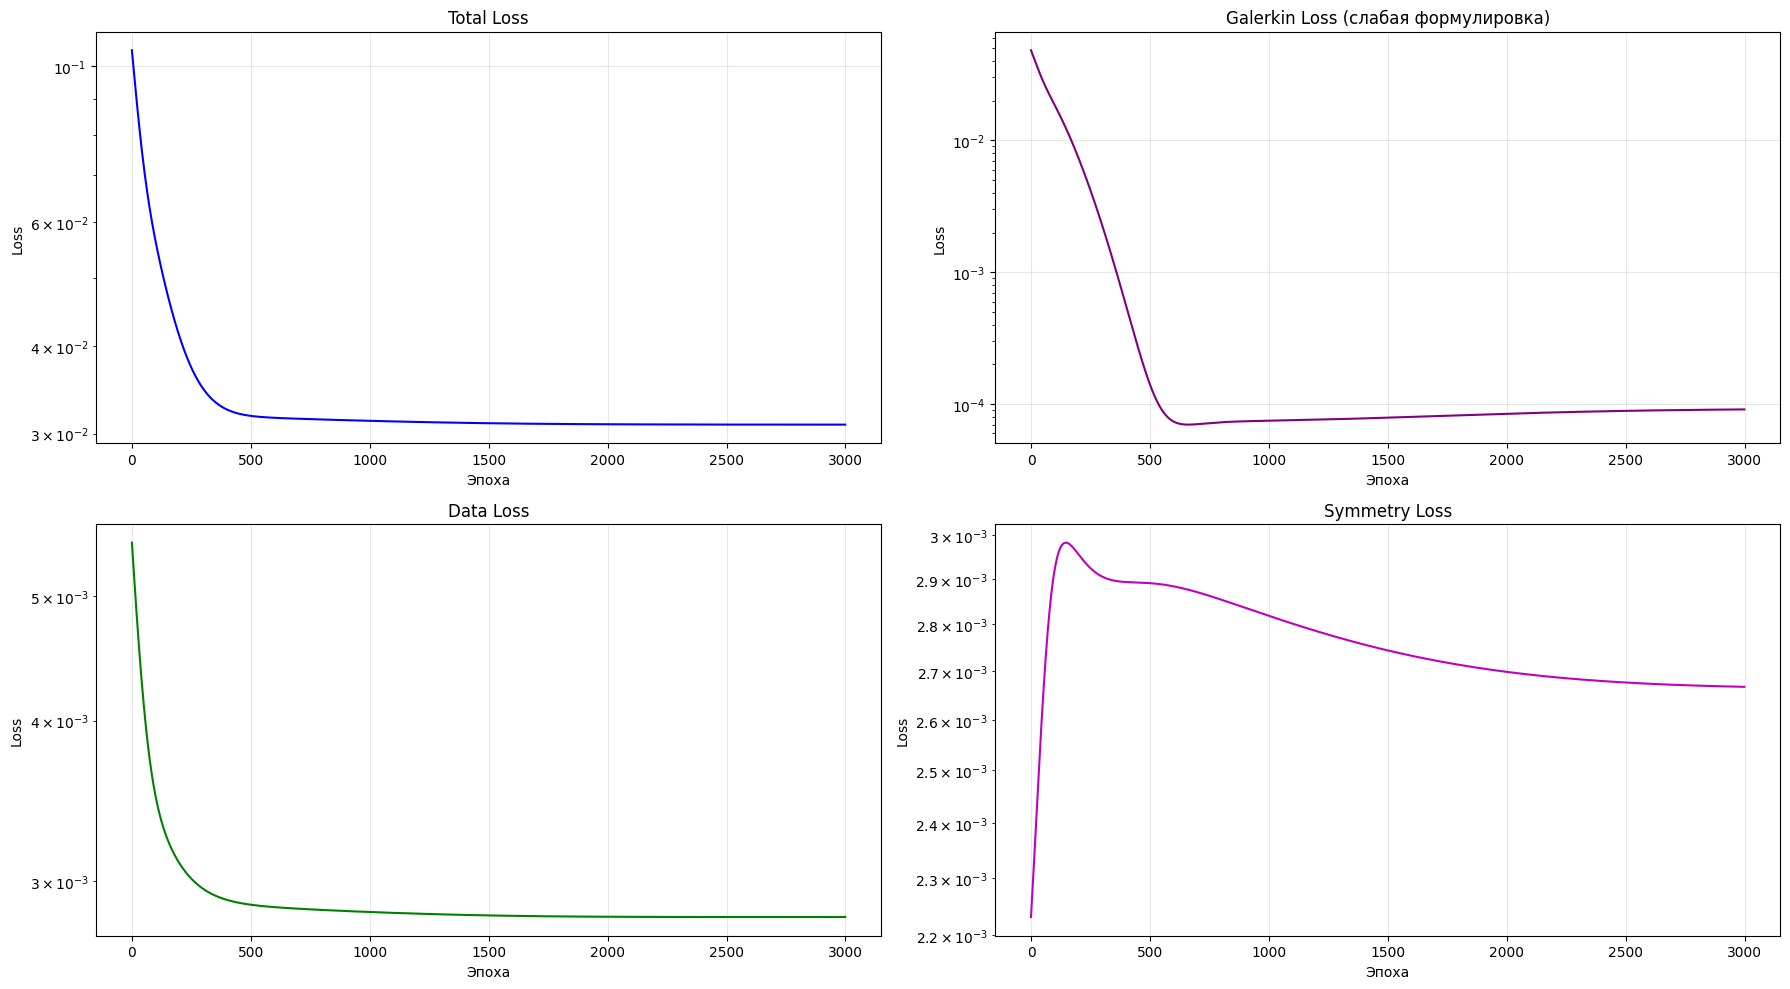

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# График общей потери
axes[0, 0].plot(history['total_loss'], 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# График Galerkin loss
axes[0, 1].plot(history['galerkin_loss'], 'purple', linewidth=1.5)
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Galerkin Loss (слабая формулировка)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# График Data loss
axes[1, 0].plot(history['data_loss'], 'g-', linewidth=1.5)
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Data Loss')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# График Symmetry loss
axes[1, 1].plot(history['symmetry_loss'], 'm-', linewidth=1.5)
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Symmetry Loss')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Сравнение с аналитическим решением

Теперь сравним предсказания нейронной сети с аналитическим решением для разных значений $x'$.

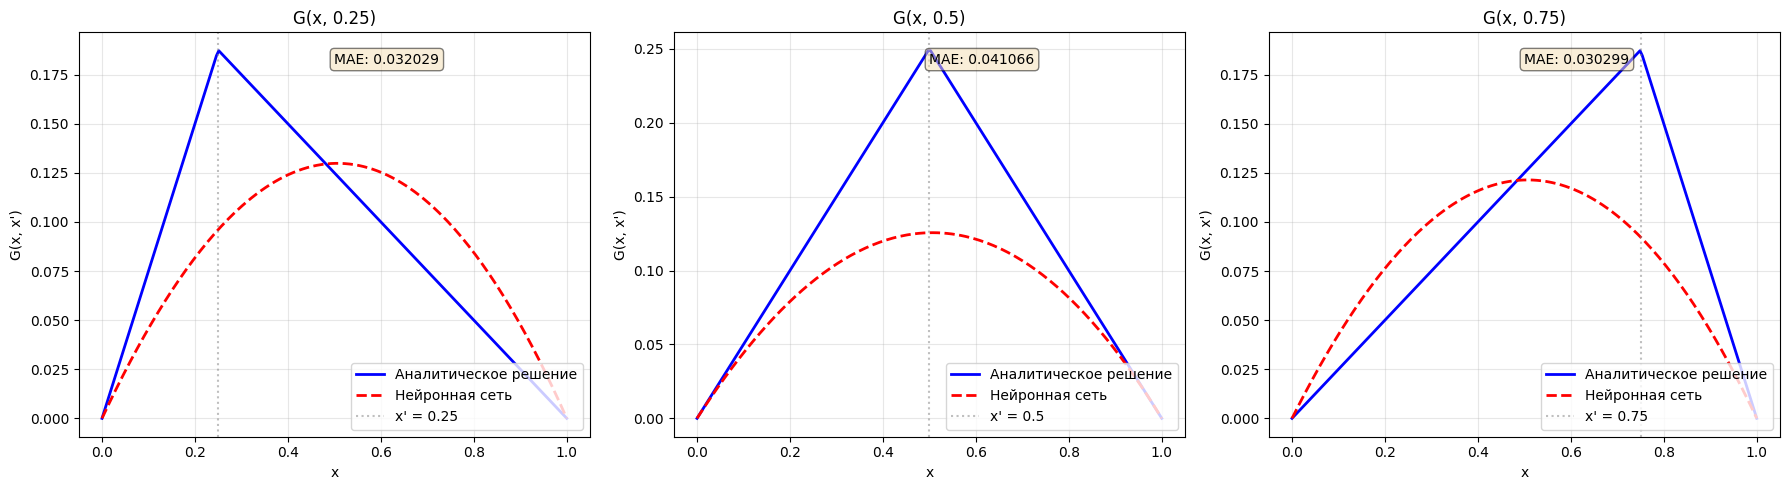

In [57]:
model.eval()

# Тестовые точки
x_test = np.linspace(0, 1, 200)
x_prime_values = [0.25, 0.5, 0.75]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, x_prime_val in enumerate(x_prime_values):
    # Аналитическое решение
    G_analytical = greens_function_analytical(x_test, x_prime_val)
    
    # Предсказание нейронной сети
    x_test_tensor = torch.FloatTensor(x_test.reshape(-1, 1)).to(device)
    x_prime_tensor = torch.FloatTensor(np.full((len(x_test), 1), x_prime_val)).to(device)
    
    with torch.no_grad():
        G_nn = model(x_test_tensor, x_prime_tensor).cpu().numpy().flatten()
    
    # Построение графиков
    axes[idx].plot(x_test, G_analytical, 'b-', linewidth=2, label='Аналитическое решение')
    axes[idx].plot(x_test, G_nn, 'r--', linewidth=2, label='Нейронная сеть')
    axes[idx].axvline(x=x_prime_val, color='gray', linestyle=':', alpha=0.5, label=f"x' = {x_prime_val}")
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel("G(x, x')")
    axes[idx].set_title(f"G(x, {x_prime_val})")
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)
    
    # Вычисление ошибки
    error = np.mean(np.abs(G_analytical - G_nn))
    axes[idx].text(0.5, 0.95, f'MAE: {error:.6f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 9. Визуализация функции Грина в 2D

Построим тепловую карту функции Грина $G(x, x')$ как функцию двух переменных.

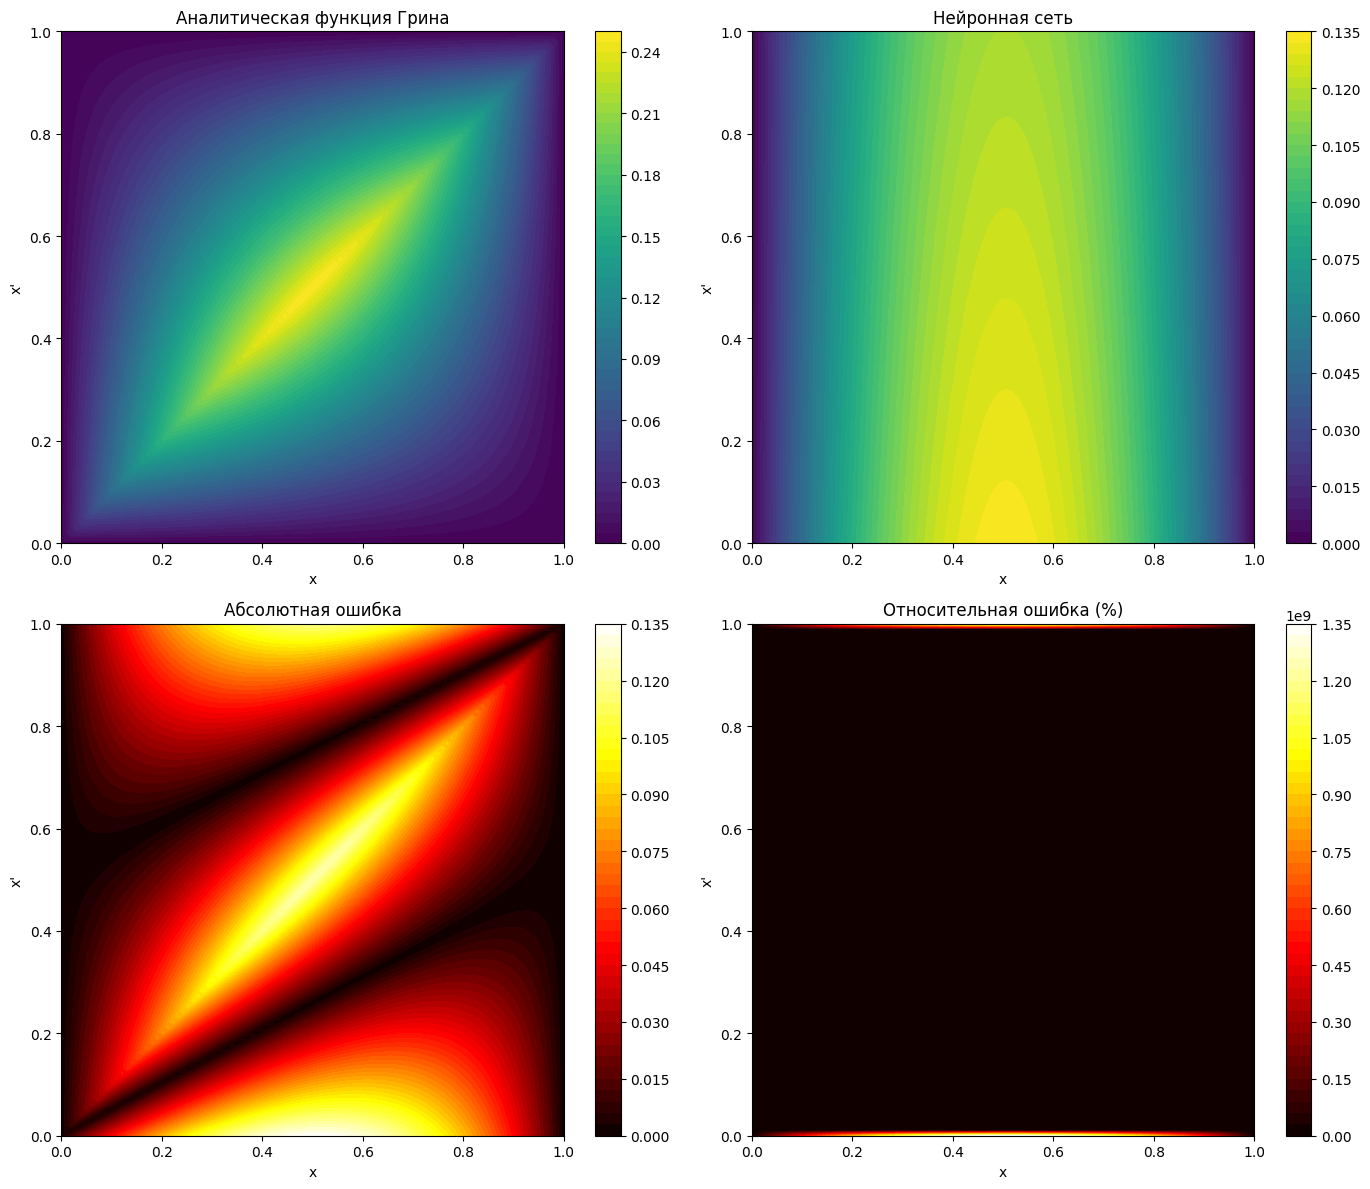


Статистика ошибок:
  Максимальная абсолютная ошибка: 0.134071
  Средняя абсолютная ошибка: 0.041723
  Средняя относительная ошибка: 16577259.07%


In [58]:
# Создание сетки
n_points = 100
x_grid = np.linspace(0, 1, n_points)
x_prime_grid = np.linspace(0, 1, n_points)
X_mesh, X_prime_mesh = np.meshgrid(x_grid, x_prime_grid)

# Аналитическое решение на сетке
G_analytical_2d = greens_function_analytical(x_grid, x_prime_grid)

# Предсказание нейронной сети на сетке
X_flat = X_mesh.flatten().reshape(-1, 1)
X_prime_flat = X_prime_mesh.flatten().reshape(-1, 1)

X_tensor = torch.FloatTensor(X_flat).to(device)
X_prime_tensor = torch.FloatTensor(X_prime_flat).to(device)

with torch.no_grad():
    G_nn_flat = model(X_tensor, X_prime_tensor).cpu().numpy()

G_nn_2d = G_nn_flat.reshape(n_points, n_points)

# Вычисление ошибки
error_2d = np.abs(G_analytical_2d - G_nn_2d)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Аналитическое решение
im1 = axes[0, 0].contourf(X_mesh, X_prime_mesh, G_analytical_2d, levels=50, cmap='viridis')
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("x'")
axes[0, 0].set_title("Аналитическая функция Грина")
plt.colorbar(im1, ax=axes[0, 0])

# Предсказание нейронной сети
im2 = axes[0, 1].contourf(X_mesh, X_prime_mesh, G_nn_2d, levels=50, cmap='viridis')
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("x'")
axes[0, 1].set_title("Нейронная сеть")
plt.colorbar(im2, ax=axes[0, 1])

# Абсолютная ошибка
im3 = axes[1, 0].contourf(X_mesh, X_prime_mesh, error_2d, levels=50, cmap='hot')
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("x'")
axes[1, 0].set_title("Абсолютная ошибка")
plt.colorbar(im3, ax=axes[1, 0])

# Относительная ошибка (в процентах)
relative_error = 100 * error_2d / (np.abs(G_analytical_2d) + 1e-8)
im4 = axes[1, 1].contourf(X_mesh, X_prime_mesh, relative_error, levels=50, cmap='hot')
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("x'")
axes[1, 1].set_title("Относительная ошибка (%)")
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print(f"\nСтатистика ошибок:")
print(f"  Максимальная абсолютная ошибка: {np.max(error_2d):.6f}")
print(f"  Средняя абсолютная ошибка: {np.mean(error_2d):.6f}")
print(f"  Средняя относительная ошибка: {np.mean(relative_error):.2f}%")

## 10. Применение: Решение уравнения Пуассона

Используем обученную функцию Грина для решения уравнения Пуассона с конкретной правой частью:

$$-\frac{d^2 u}{dx^2} = f(x)$$

Решение через функцию Грина:
$$u(x) = \int_0^1 G(x, x') f(x') dx'$$

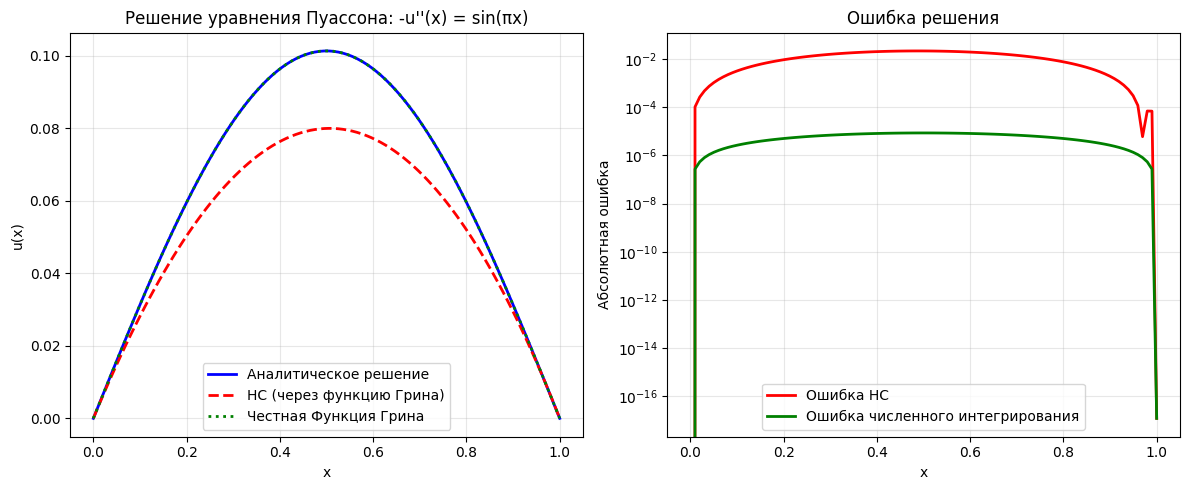


Результаты решения уравнения Пуассона:
  Средняя ошибка НС: 1.109343e-02
  Максимальная ошибка НС: 2.139484e-02
  Средняя ошибка точной функции Грина: 5.358572e-06


In [59]:
# Определим правую часть f(x) = sin(π*x)
def source_term(x):
    return np.sin(np.pi * x)

# Аналитическое решение для -u'' = sin(π*x) с u(0) = u(1) = 0
def analytical_solution(x):
    return np.sin(np.pi * x) / (np.pi**2)

# Решение с помощью функции Грина (численное интегрирование)
def solve_with_greens_function(x_eval, use_nn=True):
    """
    Решает уравнение Пуассона используя функцию Грина
    
    Args:
        x_eval: точки, в которых вычисляется решение
        use_nn: использовать нейронную сеть (True) или аналитическое решение (False)
    """
    n_integration = 100
    x_prime_integration = np.linspace(0, 1, n_integration)
    dx_prime = x_prime_integration[1] - x_prime_integration[0]
    
    u_solution = np.zeros_like(x_eval)
    
    for i, x_val in enumerate(x_eval):
        if use_nn:
            # Используем нейронную сеть
            x_tensor = torch.FloatTensor(np.full((n_integration, 1), x_val)).to(device)
            x_prime_tensor = torch.FloatTensor(x_prime_integration.reshape(-1, 1)).to(device)
            
            with torch.no_grad():
                G_vals = model(x_tensor, x_prime_tensor).cpu().numpy().flatten()
        else:
            # Используем аналитическое решение
            G_vals = greens_function_analytical(x_val, x_prime_integration)
        
        # Интегрирование: u(x) = ∫ G(x, x') * f(x') dx'
        f_vals = source_term(x_prime_integration)
        u_solution[i] = np.trapz(G_vals * f_vals, dx=dx_prime)
    
    return u_solution

# Тестовые точки
x_test_poisson = np.linspace(0, 1, 100)

# Решения
u_analytical = analytical_solution(x_test_poisson)
u_nn = solve_with_greens_function(x_test_poisson, use_nn=True)
u_exact_greens = solve_with_greens_function(x_test_poisson, use_nn=False)

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_test_poisson, u_analytical, 'b-', linewidth=2, label='Аналитическое решение')
plt.plot(x_test_poisson, u_nn, 'r--', linewidth=2, label='НС (через функцию Грина)')
plt.plot(x_test_poisson, u_exact_greens, 'g:', linewidth=2, label='Честная Функция Грина')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Решение уравнения Пуассона: -u\'\'(x) = sin(πx)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
error_nn = np.abs(u_analytical - u_nn)
error_exact = np.abs(u_analytical - u_exact_greens)
plt.plot(x_test_poisson, error_nn, 'r-', linewidth=2, label='Ошибка НС')
plt.plot(x_test_poisson, error_exact, 'g-', linewidth=2, label='Ошибка численного интегрирования')
plt.xlabel('x')
plt.ylabel('Абсолютная ошибка')
plt.title('Ошибка решения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

print(f"\nРезультаты решения уравнения Пуассона:")
print(f"  Средняя ошибка НС: {np.mean(error_nn):.6e}")
print(f"  Максимальная ошибка НС: {np.max(error_nn):.6e}")
print(f"  Средняя ошибка точной функции Грина: {np.mean(error_exact):.6e}")

## Заключение

В этом ноутбуке мы продемонстрировали:

1. **Теорию функций Грина** для дифференциальных уравнений
2. **Архитектуру нейронной сети** для аппроксимации функции Грина $G(x, x')$
3. **Метод Галёркина** для обучения сети через физически информированные функции Loss:
   - Galerkin loss: проверка выполнения дифференциального уравнения
   - Data loss: обучение на аналитическом решении
   - Symmetry loss: обеспечение симметрии функции Грина
4. **Применение** обученной функции Грина для решения уравнения Пуассона